# AR(1) Process

$$
  y_{t} = \phi y_{t-1} + \epsilon_{t},\quad \epsilon_{t}\sim\text{Normal}(0,\sigma^{2}),\quad y_{1}\sim\text{Normal}\left(0,\frac{\sigma^{2}}{1-\phi^{2}}\right).
$$

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from arviz import convert_to_inference_data, summary
# from scipy.linalg import inv, solve
from scipy.stats import gaussian_kde
from tqdm import trange

In [2]:
def mcmc_stats(runs, burnin=0, chain=4, prob=0.95, param_string=None, isvariance=True):
    """
    Posterior statistics

    Inputs
    runs         --- Monte Carlo sample
    burnin       --- the number of runs in the burnin stage
    chain        --- the number of chains used for convergence diagnostics
    prob         --- the posterior probability for interval estimation
    param_string --- the list of parameter names
    isvariance   --- True if the variance is included

    Outputs
    posterior_statistics --- table of posterior statistics (Pandas datafarme)
    """
    if runs.shape[0] < burnin:
        raise ValueError('You need to reduce the number of draws to be discarded as burnin.')
    draw = (runs.shape[0] - burnin) // chain
    if runs.shape[0] != burnin + draw * chain:
        raise ValueError('The number of draws must be divided by the number of chains.')
    if not param_string:
        if isvariance:
            param_string = [f'$\\beta_{{{i}}}$' for i in range(runs.shape[1]-1)]
            param_string.append('$\\sigma^{2}$')
        else:
            param_string = [f'$\\beta_{{{i}}}$' for i in range(runs.shape[1])]
    traces = convert_to_inference_data(np.stack([runs[burnin:, i].reshape((chain, draw)) \
                                                 for i in range(runs.shape[1])], axis=2))
    posterior_statistics = summary(traces, hdi_prob=prob)
    posterior_statistics.index = param_string
    return posterior_statistics

In [3]:
def mcmc_plots(runs, burnin=0, param_string=None, isvariance=True):
    """
    Posterior plots

    Inputs
    runs          --- Monte Carlo sample
    burnin        --- the number of runs in the burnin stage
    isvariance    --- True if the variance is included

    Outputs
    kde_x         --- grid
    kde_posterior --- kernel density estimation
    """
    grid = 250
    k = runs.shape[1]
    kde_x = np.zeros((grid, k))
    kde_posterior = np.zeros((grid, k))
    if isvariance:
        num_b = k - 1
    else:
        num_b = k
    if not param_string:
        if isvariance:
            param_string = [f'$\\beta_{{{i}}}$' for i in range(runs.shape[1]-1)]
            param_string.append('$\\sigma^{2}$')
        else:
            param_string = [f'$\\beta_{{{i}}}$' for i in range(runs.shape[1])]
    fig, ax = plt.subplots(k, 2, num=1, figsize=(8, 1.5*k), facecolor='w')
    for index in range(k):
        mc_trace = runs[burnin:, index]
        if index < num_b:
            x_min = mc_trace.min() - 0.2 * np.abs(mc_trace.min())
            x_max = mc_trace.max() + 0.2 * np.abs(mc_trace.max())
            x = np.linspace(x_min, x_max, grid)
            y_label = param_string[index]
        else:
            x_min = 0.0
            x_max = mc_trace.max() + 0.2 * np.abs(mc_trace.max())
            x = np.linspace(x_min, x_max, grid)
            y_label = param_string[index]
        posterior = gaussian_kde(mc_trace).evaluate(x)
        ax[index, 0].plot(mc_trace, linewidth=0.1)
        ax[index, 0].set_xlim(1, draws)
        ax[index, 0].set_ylabel(y_label)
        ax[index, 1].plot(x, posterior)
        ax[index, 1].set_xlim(x_min, x_max)
        ax[index, 1].set_ylim(0, 1.1*posterior.max())
        ax[index, 1].set_ylabel('Density')
        kde_x[:, index] = x
        kde_posterior[:, index] = posterior
    ax[-1, 0].set_xlabel('Random Sequence')
    ax[-1, 1].set_xlabel('Posterior Distribution')
    plt.tight_layout()
    plt.show
    return kde_x, kde_posterior

## Metropolis-Hastings Algorithm

### Priors

$$
  \frac{1+\phi}{2} \sim \text{Beta}(a_{0}, b_{0}),\quad \sigma^{2} \sim \text{Inv.Gamma}\left(\frac{\nu_{0}}{2},\frac{\lambda_{0}}{2}\right).
$$

### Full conditionals

+ $\sigma^{2}$

$$
  \sigma^{2}|\phi,D \sim \text{Inv.Gamma}\left(\frac{n+\nu_{0}}2,
  \frac12\left\{\sum_{t=1}^{n}y_{t}^{2}-2\phi\sum_{t=2}^{n}y_{t}y_{t-1}+\phi^{2}\sum_{t=2}^{n-1}y_{t}^{2}+\lambda_{0}\right\}\right).
$$

+ $\phi$

$$
    p(\phi|\sigma^{2},D) \propto \sqrt{1-\phi^{2}}(1+\phi)^{\alpha_{\phi}-1}(1-\phi)^{\beta_{\phi}-1}
    \exp\left[-\frac{\sum_{t=2}^{n-1}y_{t}^{2}}{2\sigma^{2}}
    \left(\phi-\frac{\sum_{t=2}^{n}y_{t}y_{t-1}}{\sum_{t=2}^{n-1}y_{t}^{2}}\right)^{2}\right]1_{(-1,1)}(\phi).
$$

### Random Walk Chain

$$
  \tilde\theta = \theta^{(r-1)} + c\epsilon,\quad \epsilon \sim \text{Normal}\left(0,\frac{\sigma^{2}}{\sum_{t=2}^{n-1}y_{t}^{2}}\right),
$$

where $c>0$ is the tuning parameter.


In [4]:
def mh_ar1_rw(y, hyper_param, c=1.0, burnin=1000, draws=10000, rng=None):
    if rng == None:
        rng = np.random.default_rng(seed=1234)
    iterations = burnin + draws
    a0, b0, nu0, lam0 = hyper_param
    n = y.shape[0]
    sum1 = np.square(y).sum()
    sum2 = np.sum(y[1:] * y[:-1])
    sum3 = np.square(y[1:-1]).sum()
    mean_phi = sum2 / sum3
    phi = mean_phi
    nu_star = 0.5 * (n + nu0)
    runs = np.empty((iterations, 2))
    accept = 0.0
    for it in trange(iterations):
        lam_star = 0.5 * (sum1 - 2.0 * phi * sum2 + phi**2 * sum3 + lam0)
        sigma2 = lam_star / rng.gamma(nu_star)
        flag = True
        while flag:
            phi_tmp = rng.normal(loc=phi, scale=c*np.sqrt(sigma2/sum3))
            if -1.0 < phi_tmp < 1.0:
                flag = False
        prob = min(np.exp((a0 - 0.5)*np.log(1.0 + phi_tmp) + (b0 - 0.5) * np.log(1.0 - phi_tmp)  \
                          - (a0 - 0.5)*np.log(1.0 + phi) - (b0 - 0.5) * np.log(1.0 - phi) \
                          - 0.5*sum3/sigma2*((phi_tmp-mean_phi)**2 - (phi-mean_phi)**2)), 1.0)
        u = rng.uniform()
        if u <= prob:
            phi = phi_tmp
            accept += 1.0
        runs[it, :] = np.hstack((phi, sigma2))
    return runs, accept/iterations

## Independent Chain

### The proposal distribution for $\phi$

$$
  \phi|\sigma^{2},D \sim \text{Normal}_{(-1,1)}\left(\frac{\sum_{t=2}^{n}y_{t}y_{t-1}}{\sum_{t=2}^{n-1}y_{t}^{2}},
  \frac{\sigma^{2}}{\sum_{t=2}^{n-1}y_{t}^{2}}\right).
$$

### Acceptance probability

$$
  \alpha(\varphi,\phi) = \min\left\{
  \frac{\sqrt{1-\phi^{2}}(1+\phi)^{a_0-1}(1-\phi)^{b_0-1}}
  {\sqrt{1-\varphi^{2}}(1+\varphi)^{a_0-1}(1-\varphi)^{b_0-1}}, 1
  \right\}
  = \min\left\{
  \frac{(1+\phi)^{a_0-1/2}(1-\phi)^{b_0-1/2}}
  {(1+\varphi)^{a_0-1/2}(1-\varphi)^{b_0-1/2}}, 1
  \right\}.
$$


In [5]:
def mh_ar1_ic(y, hyper_param, burnin=1000, draws=10000, rng=None):
    if rng == None:
        rng = np.random.default_rng(seed=1234)
    iterations = burnin + draws
    a0, b0, nu0, lam0 = hyper_param
    n = y.shape[0]
    sum1 = np.square(y).sum()
    sum2 = np.sum(y[1:] * y[:-1])
    sum3 = np.square(y[1:-1]).sum()
    mean_phi = sum2 / sum3
    phi = mean_phi
    nu_star = 0.5 * (n + nu0)
    runs = np.empty((iterations, 2))
    accept = 0.0
    for it in trange(iterations):
        lam_star = 0.5 * (sum1 - 2.0 * phi * sum2 + phi**2 * sum3 + lam0)
        sigma2 = lam_star / rng.gamma(nu_star)
        flag = True
        while flag:
            phi_tmp = rng.normal(loc=mean_phi, scale=np.sqrt(sigma2/sum3))
            if -1.0 < phi_tmp < 1.0:
                flag = False
        prob = min(np.exp((a0 - 0.5)*np.log(1.0 + phi_tmp) + (b0 - 0.5) * np.log(1.0 - phi_tmp) \
                          - (a0 - 0.5)*np.log(1.0 + phi) - (b0 - 0.5) * np.log(1.0 - phi)), 1.0)
        u = rng.uniform()
        if u <= prob:
            phi = phi_tmp
            accept += 1.0
        runs[it, :] = np.hstack((phi, sigma2))
    return runs, accept/iterations

## Generate time series data from the AR(1) process

$$
 n = 500,\quad \phi = 0.9,\quad \sigma^{2} = 0.19.
$$


In [6]:
n = 500
rng = np.random.default_rng(seed=99)
y = np.empty(n)
y[0] = rng.normal() # invariant variance = 0.19/(1 - 0.9**2) = 1.0
for t in range(1, n):
    y[t] = 0.9 * y[t-1] + rng.normal(scale=np.sqrt(0.19))

## Time series plot


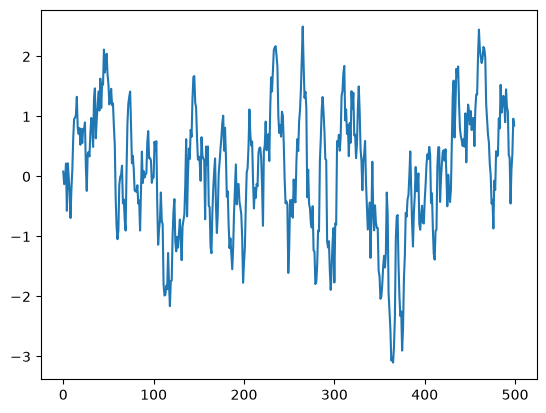

In [7]:
plt.plot(y)
plt.show()

In [8]:
params = ['$\\phi$', '$\\sigma^{2}$']
# a0 = b0 = 1.0 # Uniform prior
a0 = b0 = 0.5 # Jeffreys prior
nu0 = 0.002
lam0 = 0.002
hyper_param = [a0, b0, nu0, lam0]
burnin = 2000
draws = 20000

In [9]:
runs_ar1_rw, accept_ar1_rw = mh_ar1_rw(y, hyper_param, c=2.0, burnin=burnin, draws=draws, rng=rng)

100%|███████████████████████████████████████████| 22000/22000 [00:00<00:00, 170306.32it/s]


In [10]:
runs_ar1_ic, accept_ar1_ic = mh_ar1_ic(y, hyper_param, burnin=burnin, draws=draws, rng=rng)

100%|███████████████████████████████████████████| 22000/22000 [00:00<00:00, 198221.51it/s]


In [11]:
results_ar1_rw = mcmc_stats(runs_ar1_rw, burnin=burnin, param_string=params, isvariance=False)
display(results_ar1_rw)
print(f'Acceptance Rate of MH Algorithm = {100*accept_ar1_rw:.2f}%')

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
$\phi$,0.905,0.019,0.866,0.939,0.0,0.0,4646.0,5537.0,1.0
$\sigma^{2}$,0.199,0.013,0.175,0.224,0.0,0.0,19926.0,19739.0,1.0


Acceptance Rate of MH Algorithm = 51.20%


In [12]:
results_ar1_ic = mcmc_stats(runs_ar1_ic, burnin=burnin, param_string=params, isvariance=False)
display(results_ar1_ic)
print(f'Acceptance Rate of MH Algorithm = {100*accept_ar1_ic:.2f}%')

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
$\phi$,0.905,0.019,0.867,0.942,0.0,0.0,20026.0,20209.0,1.0
$\sigma^{2}$,0.199,0.013,0.174,0.224,0.0,0.0,20273.0,19694.0,1.0


Acceptance Rate of MH Algorithm = 100.00%


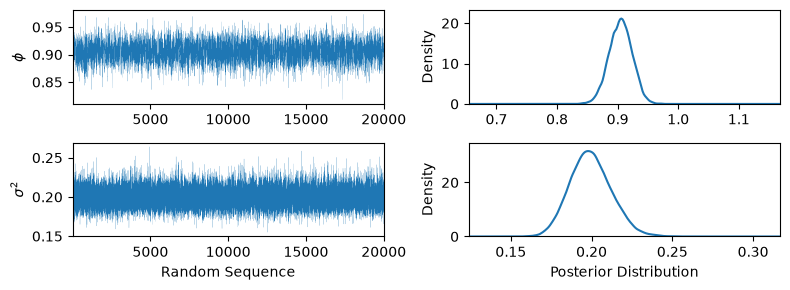

In [13]:
_ = mcmc_plots(runs_ar1_rw, burnin=burnin, param_string=params, isvariance=False)

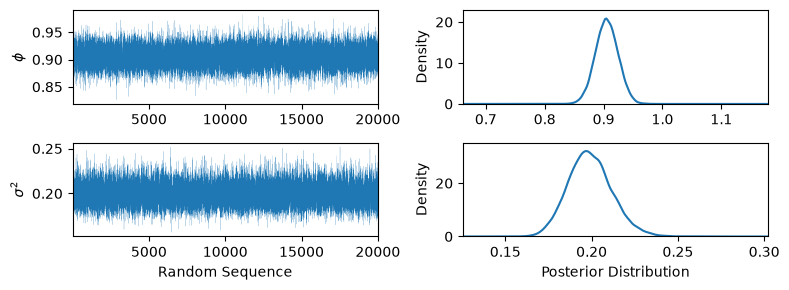

In [14]:
_ = mcmc_plots(runs_ar1_ic, burnin=burnin, param_string=params, isvariance=False)